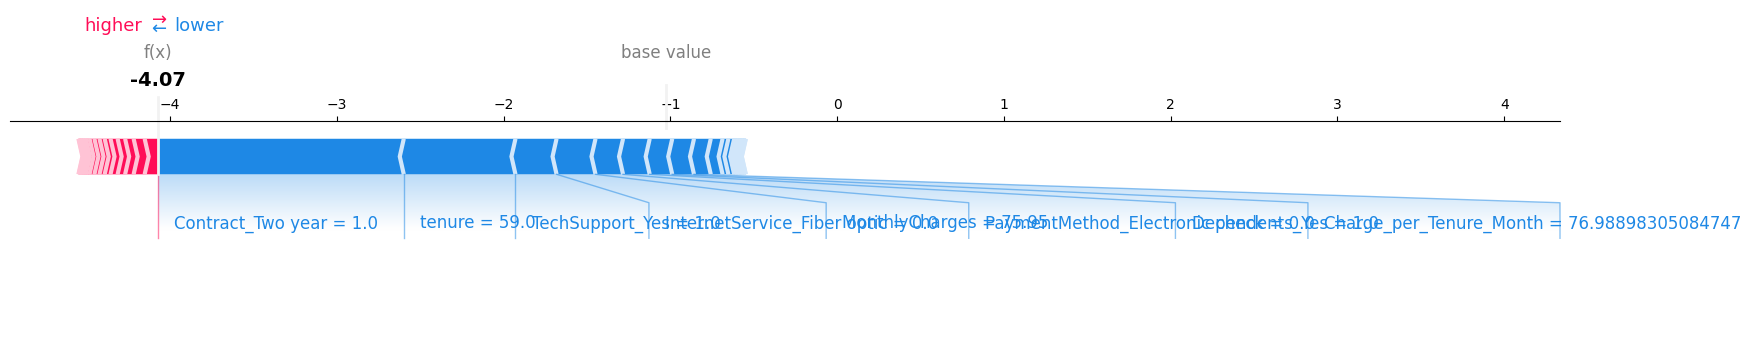

In [8]:
customer_index = 0
shap.force_plot(
    explainer.expected_value,
    shap_values[customer_index],
    X_test.iloc[customer_index],
    matplotlib=True
)

plt.show()

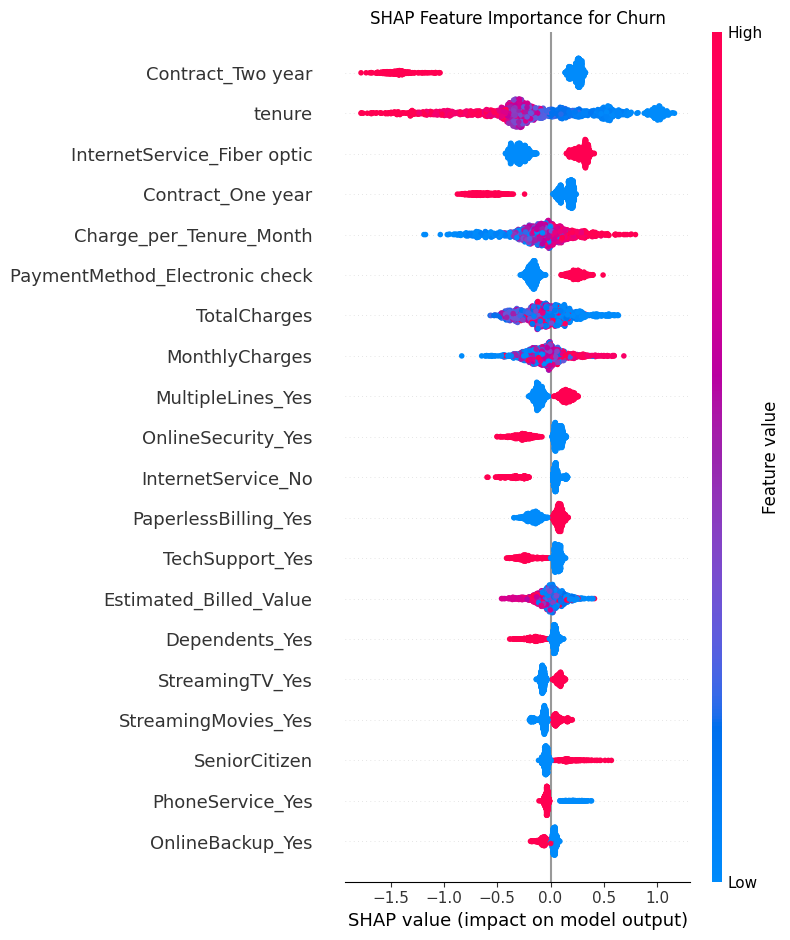

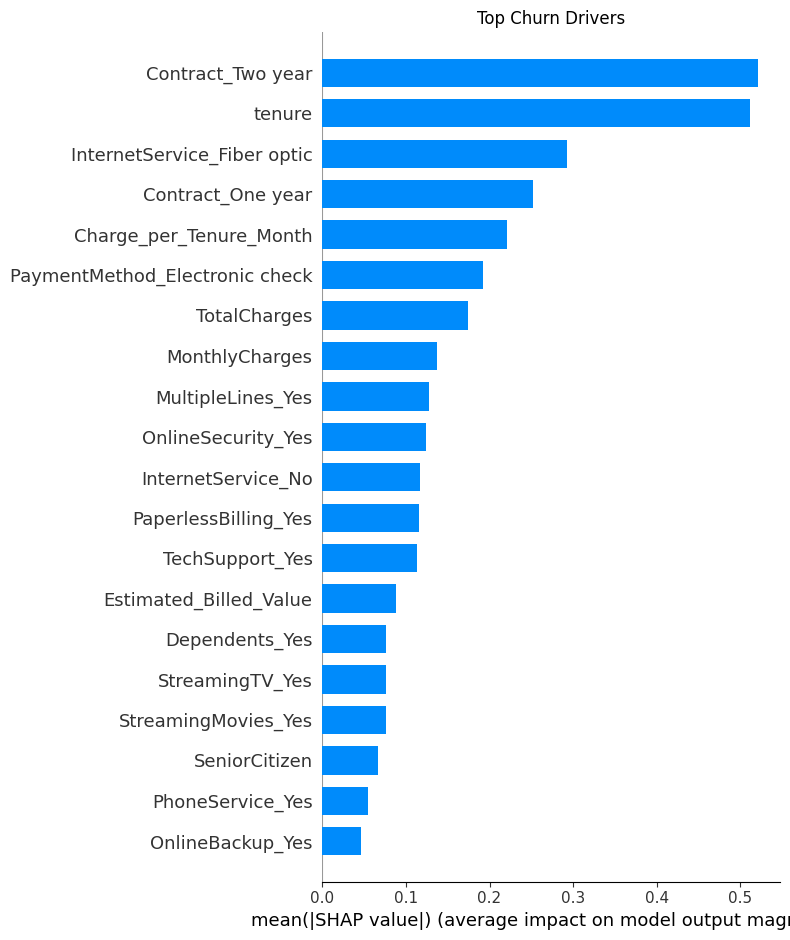

<Figure size 640x480 with 0 Axes>

In [7]:
import shap
import matplotlib.pyplot as plt
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Feature Importance for Churn")
plt.tight_layout()
plt.show()

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("Top Churn Drivers")
plt.tight_layout()
plt.show()

plt.savefig(
    "../outputs/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

In [3]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X_raw = data.drop(
    columns=[
        "customerID",
        "Churn",
        "Churn_Target"
    ]
)

y = data["Churn_Target"]

X = pd.get_dummies(
    X_raw,
    drop_first=True
)

X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

best_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

best_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [9]:
import pandas as pd
import numpy as np
import joblib

best_model = joblib.load(
    "../outputs/best_xgboost_model.pkl"
)

print("Best model loaded successfully.")
data = pd.read_csv(
    "../data/processed/customer_master.csv"
)

print(data.shape)

Best model loaded successfully.
(7032, 27)


c:\Users\susha\AppData\Local\Programs\Python\Python310\lib\pickle.py:1718: UserWarning: [01:41:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\data\../common/error_msg.h:82: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)
